In [2]:
import scanpy as sc
import anndata as ad

# Load the AnnData
ge_adata = ad.read_h5ad("/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION/MODEL_INPUT/042025/ge_adata_matched_with_linearSCVI_2025-04-29.h5ad")


In [3]:
ge_adata.obs.iloc[100][0:20]

cell_id                                    A10_B001750
age                                                 3m
cell_ontology_class    CD8-positive, alpha-beta T cell
mouse.id                                        3_38_F
sex                                             female
subtissue                                          nan
tissue                                          Spleen
dataset                             tabula_muris_senis
batch                               tabula_muris_senis
cell_id_index                                      100
cell_name                                  A10_B001750
library_size                                 84.043342
_scvi_batch                                          1
_scvi_labels                                         0
Z_0                                          -0.311546
Z_1                                          -0.315509
Z_2                                          -1.011962
Z_3                                           0.349095
Z_4       

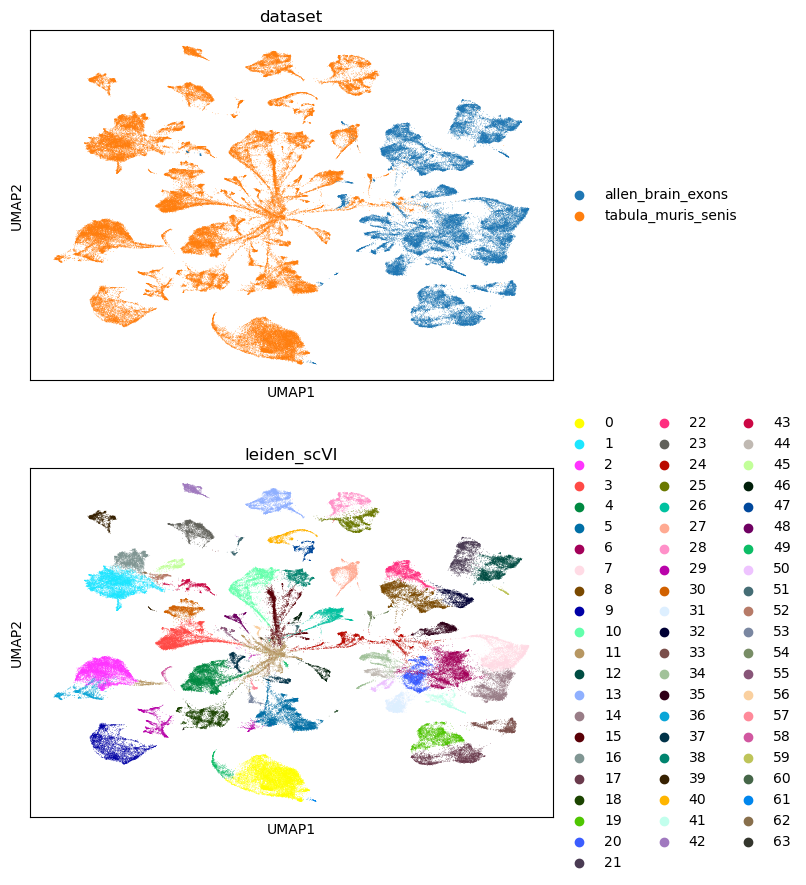

In [4]:
sc.pl.umap(
    ge_adata,
    color=["dataset", "leiden_scVI"],
    ncols=1
)


In [10]:
# Complete cell type classification dictionary
cell_type_mappings = {
    # Broad cell type map (previously separate)
    "Micro-PVM": "MICROGLIA",
    "Astro": "GLIAL CELL",
    "Oligo": "GLIAL CELL",
    "VLMC": "VLMCs",
    "Endo": "ENDOTHELIAL CELL",
    "SMC-Peri": "PERICYTE",
    
    # Car3+ special case
    "Car3": "Other non-neuronal (Car3+)",
    
    # Inhibitory neuron markers
    "Sst": "Inhibitory Neurons",
    "Pvalb": "Inhibitory Neurons",
    "Vip": "Inhibitory Neurons",
    "Lamp5": "Inhibitory Neurons",
    "Sncg": "Inhibitory Neurons",
    "Meis2": "Inhibitory Neurons",
    "Ntng1": "Inhibitory Neurons",
    "Pax6": "Inhibitory Neurons",
    "CR": "Inhibitory Neurons",
    
    # Excitatory neuron layer markers
    "L2": "Excitatory Neurons",
    "L3": "Excitatory Neurons",
    "L4": "Excitatory Neurons",
    "L5": "Excitatory Neurons",
    "L6": "Excitatory Neurons",
    
    # Excitatory subregions (hippocampal/entorhinal)
    "CA1": "Excitatory Neurons",
    "CA2": "Excitatory Neurons",
    "CA3": "Excitatory Neurons",
    "DG": "Excitatory Neurons",
    "SUB": "Excitatory Neurons",
    "ProS": "Excitatory Neurons",
    "HATA": "Excitatory Neurons",
    "Mossy": "Excitatory Neurons",
    "PPP": "Excitatory Neurons",
    "RHP": "Excitatory Neurons",
    
    # Excitatory region markers
    "IT": "Excitatory Neurons",
    "CT": "Excitatory Neurons",
    "PT": "Excitatory Neurons",
    "NP": "Excitatory Neurons",
    "CTX": "Excitatory Neurons",
    "ENT": "Excitatory Neurons",
    "PAR": "Excitatory Neurons",
    "POST": "Excitatory Neurons",
    "RSP": "Excitatory Neurons",
    "HPF": "Excitatory Neurons",
    
    # Basal cells
    'basal cell of epidermis': 'BASAL CELL',
    'basal cell': 'BASAL CELL',

    # Endothelial cells
    'endothelial cell': 'ENDOTHELIAL CELL',
    'endothelial cell of coronary artery': 'ENDOTHELIAL CELL',
    'endothelial cell of hepatic sinusoid': 'ENDOTHELIAL CELL',
    'aortic endothelial cell': 'ENDOTHELIAL CELL',
    'vein endothelial cell': 'ENDOTHELIAL CELL',
    'endothelial cell of lymphatic vessel': 'ENDOTHELIAL CELL',

    # T cells
    'T cell': 'T CELL',
    'CD4-positive, alpha-beta T cell': 'T CELL',
    'CD8-positive, alpha-beta T cell': 'T CELL',
    'regulatory T cell': 'T CELL',
    'mature NK T cell': 'T CELL',
    'mature alpha-beta T cell': 'T CELL',
    
    # B cells
    'B cell': 'B CELL',
    'immature B cell': 'B CELL',
    'naive B cell': 'B CELL',
    'precursor B cell': 'B CELL',
    'early pro-B cell': 'B CELL',
    'late pro-B cell': 'B CELL',
    'plasma cell': 'B CELL',

    # Fibroblasts
    'fibroblast': 'FIBROBLAST',
    'fibroblast of cardiac tissue': 'FIBROBLAST',
    'fibroblast of lung': 'FIBROBLAST',
    'pulmonary interstitial fibroblast': 'FIBROBLAST',
    'kidney interstitial fibroblast': 'FIBROBLAST',
    'fibrocyte': 'FIBROBLAST',

    # Macrophages 
    'macrophage': 'MACROPHAGE',
    'Kupffer cell': 'MACROPHAGE',  # macrophages in the liver
    'lung macrophage': 'MACROPHAGE',

    # Monocytes
    'monocyte': 'MONOCYTE',
    'classical monocyte': 'MONOCYTE',
    'non-classical monocyte': 'MONOCYTE',
    'intermediate monocyte': 'MONOCYTE',

    # General Immune Cells
    'granulocyte': 'GRANULOCYTE',
    'basophil': 'GRANULOCYTE', 
    'granulocyte monocyte progenitor cell': 'GRANULOCYTE',

    'leukocyte': 'GENERAL IMMUNE CELL',
    'professional antigen presenting cell': 'ANTIGEN PRESENTING CELL',

    'lymphocyte': 'LYMPHOID IMMUNE CELL',
    'NK cell': 'LYMPHOID IMMUNE CELL',

    'myeloid cell': 'MYELOID IMMUNE CELL',
    'myeloid leukocyte': 'MYELOID IMMUNE CELL',
    'granulocytopoietic cell': 'MYELOID IMMUNE CELL',
    'promonocyte': 'MYELOID IMMUNE CELL',

    'thymocyte': 'THYMOCYTE',
    'DN4 thymocyte': 'THYMOCYTE',

    # Neutrophils
    'neutrophil': 'NEUTROPHIL',

    # Dendritic Cells
    'dendritic cell': 'DENDRITIC CELL',
    'plasmacytoid dendritic cell': 'DENDRITIC CELL',
    'myeloid dendritic cell': 'DENDRITIC CELL',

    # Microglia (Brain Immune Cells)
    'microglial cell': 'MICROGLIA',
    
    # Pancreatic cells
    'pancreatic A cell': 'PANCREATIC CELL',
    'pancreatic B cell': 'PANCREATIC CELL',
    'pancreatic D cell': 'PANCREATIC CELL',
    'pancreatic acinar cell': 'PANCREATIC CELL',
    'pancreatic PP cell': 'PANCREATIC CELL',
    'pancreatic ductal cell': 'PANCREATIC CELL',
    'pancreatic stellate cell': 'PANCREATIC CELL',
    
    # Smooth muscle cells
    'smooth muscle cell': 'SMOOTH MUSCLE CELL',
    'bronchial smooth muscle cell': 'SMOOTH MUSCLE CELL',
    'smooth muscle cell of the pulmonary artery': 'SMOOTH MUSCLE CELL',
    'smooth muscle cell of trachea': 'SMOOTH MUSCLE CELL',
    
    # Epithelial cells
    'epithelial cell': 'EPITHELIAL CELL',
    'epidermal cell': 'EPITHELIAL CELL',
    'epithelial cell of large intestine': 'EPITHELIAL CELL',
    'enterocyte of epithelium of large intestine': 'EPITHELIAL CELL',
    'epithelial cell of proximal tubule': 'EPITHELIAL CELL',
    'epithelial cell of thymus': 'EPITHELIAL CELL',
    'bladder urothelial cell': 'EPITHELIAL CELL',
    'basal epithelial cell of tracheobronchial tree': 'EPITHELIAL CELL',
    'luminal epithelial cell of mammary gland': 'EPITHELIAL CELL',

    # Neurons
    'neuron': 'NEURON',
    'medium spiny neuron': 'NEURON',
    'interneuron': 'NEURON',
    'neuronal stem cell': 'NEURON',

    # Glial Cells (excluding microglia)
    'oligodendrocyte': 'GLIAL CELL',
    'oligodendrocyte precursor cell': 'GLIAL CELL',
    'astrocyte': 'GLIAL CELL',
    'Bergmann glial cell': 'GLIAL CELL',
    'ependymal cell': 'GLIAL CELL',

    # Stem cells
    'mesenchymal stem cell': 'STEM CELL',
    'mesenchymal stem cell of adipose': 'STEM CELL',
    'hematopoietic stem cell': 'STEM CELL',
    'neuronal stem cell': 'STEM CELL',
    'intestinal crypt stem cell': 'STEM CELL',
    'keratinocyte stem cell': 'STEM CELL',
    'lymphoid progenitor cell': 'STEM CELL',
    'proerythroblast': 'STEM CELL',
    'megakaryocyte-erythroid progenitor cell': 'STEM CELL',

    # Other specialized cells
    'ventricular myocyte': 'CARDIAC MUSCLE CELL',
    'atrial myocyte': 'CARDIAC MUSCLE CELL',
    'skeletal muscle satellite cell': 'SKELETAL MUSCLE CELL',
    'kidney collecting duct principal cell': 'KIDNEY CELL',
    'kidney collecting duct epithelial cell': 'KIDNEY CELL',
    'kidney interstitial fibroblast': 'FIBROBLAST',
    'mesangial cell': 'KIDNEY CELL',
    'type I pneumocyte': 'LUNG CELL',
    'type II pneumocyte': 'LUNG CELL',
    'club cell of bronchiole': 'LUNG CELL',
    'lung neuroendocrine cell': 'LUNG CELL',
    'ciliated columnar cell of tracheobronchial tree': 'LUNG CELL',
    'respiratory basal cell': 'LUNG CELL',
    'Brush cell of epithelium proper of large intestine': 'INTESTINAL CELL',
    'large intestine goblet cell': 'INTESTINAL CELL',
    'enteroendocrine cell': 'INTESTINAL CELL',
    'stromal cell': 'STROMAL CELL',
    'pericyte cell': 'PERICYTE',
    'brain pericyte': 'PERICYTE',
    'adventitial cell': 'STROMAL CELL',
    'keratinocyte': 'KERATINOCYTE',
    'bulge keratinocyte': 'KERATINOCYTE',
    'hepatocyte': 'HEPATOCYTE',
    'bladder cell': 'BLADDER CELL',
    'secretory cell': 'SECRETORY CELL',
    'endocardial cell': 'ENDOCARDIAL CELL',
    'valve cell': 'VALVE CELL',
    'chondrocyte': 'STROMAL CELL',
    'fenestrated cell': 'FENESTRATED CELL',
    'neuroepithelial cell': 'NEUROEPITHELIAL CELL',
    'kidney loop of Henle ascending limb epithelial cell': 'KIDNEY CELL',
    'mucus secreting cell': 'SECRETORY CELL'
}

# Subtissue corrections remain separate as they serve a different purpose
subtissue_corrections = {
    'T cells': 'T-cells',
    'ENDOMUCIN': 'Endomucin',
    'forelimb and hindlimb': 'ForelimbandHindlimb',
    'Liver non-hepato/SCs_st': 'Liver non-hepato/SCs',
    'Skin Anagen': 'Anagen'
}

# Remove any leading/trailing whitespace from subtissue values
ge_adata.obs['subtissue'] = ge_adata.obs['subtissue'].str.strip()
ge_adata.obs['subtissue_clean'] = ge_adata.obs['subtissue'].replace(subtissue_corrections)

# Drop the old subtissue 
ge_adata.obs.drop(columns=['subtissue'], inplace=True)

# Add new cell type groupings 
ge_adata.obs['cell_ontology_class'] = ge_adata.obs['cell_ontology_class'].astype(str)

# Create a function to map cell types based on pattern matching instead of exact matching
def map_cell_type(cell_label):
    # Handle special cases with Car3+
    if "Car3" in cell_label:
        return "Other non-neuronal (Car3+)"
    
    # Check for inhibitory neuron markers
    inhibitory_markers = ["Sst", "Pvalb", "Vip", "Lamp5", "Sncg", "Meis2", "Ntng1", "Pax6", "CR"]
    if any(marker in cell_label for marker in inhibitory_markers):
        return "Inhibitory Neurons"
    
    # Check for excitatory neuron markers
    layer_markers = ["L2", "L3", "L4", "L5", "L6"]
    excitatory_regions = ["CA1", "CA2", "CA3", "DG", "SUB", "ProS", "HATA", "Mossy", "PPP", "RHP"]
    other_excitatory = ["IT", "CT", "PT", "NP", "CTX", "ENT", "PAR", "POST", "RSP", "HPF"]
    
    if (any(marker in cell_label for marker in layer_markers) or
        any(marker in cell_label for marker in excitatory_regions) or
        any(marker in cell_label for marker in other_excitatory)):
        return "Excitatory Neurons"
    
    # Check for broad cell type markers
    broad_markers = {
        "Micro-PVM": "MICROGLIA",
        "Astro": "GLIAL CELL",
        "Oligo": "GLIAL CELL",
        "VLMC": "VLMCs",
        "Endo": "ENDOTHELIAL CELL",
        "SMC-Peri": "PERICYTE"
    }
    
    for marker, cell_type in broad_markers.items():
        if marker in cell_label:
            return cell_type
    
    # Check for direct matches in the main dictionary
    if cell_label in cell_type_mappings:
        return cell_type_mappings[cell_label]
    
    # Default: return the original label
    return cell_label

# Apply the mapping function to each cell
ge_adata.obs['broad_cell_type'] = ge_adata.obs['cell_ontology_class'].apply(map_cell_type)

In [14]:
ge_adata.obs["broad_cell_type"].value_counts()

broad_cell_type
Excitatory Neurons            33299
Inhibitory Neurons            15940
MICROGLIA                     12921
STEM CELL                     10943
B CELL                        10218
ENDOTHELIAL CELL               8839
EPITHELIAL CELL                7709
FIBROBLAST                     5715
BASAL CELL                     5332
MYELOID IMMUNE CELL            4105
T CELL                         4063
GLIAL CELL                     3744
KERATINOCYTE                   3718
THYMOCYTE                      3326
GRANULOCYTE                    3222
PANCREATIC CELL                3003
SKELETAL MUSCLE CELL           2682
MACROPHAGE                     2678
SMOOTH MUSCLE CELL             2273
INTESTINAL CELL                1885
MONOCYTE                       1601
HEPATOCYTE                     1152
BLADDER CELL                    938
LYMPHOID IMMUNE CELL            855
STROMAL CELL                    823
KIDNEY CELL                     805
NEURON                          794
Other non-ne

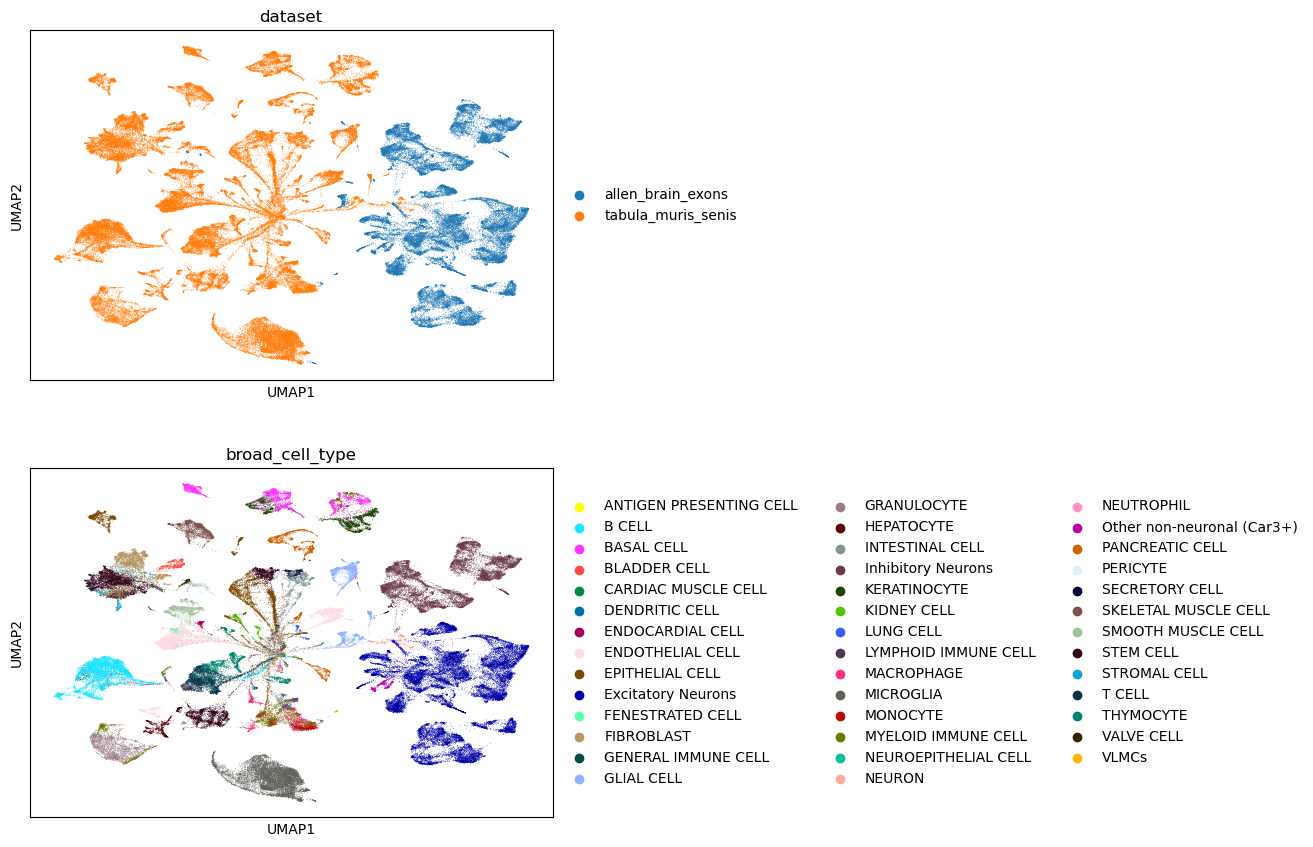

In [15]:
# Step 2: Plot UMAP colored by 'dataset'
sc.pl.umap(
    ge_adata,
    color=["dataset", "broad_cell_type"],
    ncols=1
)